# Лабораторная работа №4
Источник датасета: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

## Цель работы
Изучение линейных моделей, метода опорных векторов (SVM) и деревьев решений
на примере задачи классификации заявок на получение кредита.

## Выполненные задачи

1. Выбран датасет для решения задачи классификации
2. Проведена предобработка данных:
   - Удалён столбец `loan_id` как незначимый
   - Исправлена аномалия в `residential_assets_value` (отрицательные значения заменены на 0)
   - Выполнено кодирование категориальных признаков (`education`, `self_employed`, `loan_status`) с помощью `LabelEncoder`
3. Данные разделены на обучающую (80%) и тестовую (20%) выборки с помощью `train_test_split`
4. Обучены три модели:
   - Логистическая регрессия
   - Метод опорных векторов (SVM)
   - Дерево решений
5. Качество моделей оценено с помощью метрик **Accuracy** и **F1-score**
6. Построен график важности признаков дерева решений
7. Визуализировано дерево решений и выведены его правила в текстовом виде

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score

In [12]:
df = pd.read_csv('loan_approval_dataset.csv')

print("Размер датасета:", df.shape)
print("\nПервые строки:")
df.head()

Размер датасета: (4269, 13)

Первые строки:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [13]:
print("\nИнформация о колонках:")
df.info()
print("\nСтатистика:")
df.describe()


Информация о колонках:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB

Статистика:


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [4]:
# Удаляем ненужную колонку
df.drop(columns=['loan_id'], inplace=True)

# Убираем пробелы в названиях колонок
df.columns = df.columns.str.strip()

# Исправляем аномалию в residential_assets_value
df['residential_assets_value'] = df['residential_assets_value'].clip(lower=0)

# Кодируем категориальные признаки
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])        # Graduate=0, Not Graduate=1
df['self_employed'] = le.fit_transform(df['self_employed']) # No=0, Yes=1
df['loan_status'] = le.fit_transform(df['loan_status'])     # Approved=0, Rejected=1

print("Датасет после предобработки:")
print(df.head())
print("\nТипы данных:")
print(df.dtypes)
print("\nПроверка аномалии:")
print("Минимум residential_assets_value:", df['residential_assets_value'].min())

Датасет после предобработки:
   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asse

In [5]:
X = df.drop(columns=['loan_status'])  # признаки
y = df['loan_status']                 # целевая переменная

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% — тест, 80% — обучение
    random_state=42,  # фиксируем случайность для воспроизводимости
    stratify=y        # сохраняем пропорции Approved/Rejected
)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка:  {X_test.shape[0]} примеров")
print(f"\nПропорции классов в train:")
print(y_train.value_counts(normalize=True).round(2))
print(f"\nПропорции классов в test:")
print(y_test.value_counts(normalize=True).round(2))

# Масштабирование для LogReg и SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Обучающая выборка: 3415 примеров
Тестовая выборка:  854 примеров

Пропорции классов в train:
loan_status
0    0.62
1    0.38
Name: proportion, dtype: float64

Пропорции классов в test:
loan_status
0    0.62
1    0.38
Name: proportion, dtype: float64


In [6]:
# Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Логистическая регрессия обучена!")

# SVM
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)
print("SVM обучена!")

# Дерево решений
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
print("Дерево решений обучено!")

Логистическая регрессия обучена!
SVM обучена!
Дерево решений обучено!


In [7]:
models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'SVM':                 (svm,     X_test_scaled),
    'Decision Tree':       (tree,    X_test),
}

print(f"{'Модель':<25} {'Accuracy':>10} {'F1-score':>10}")
print("-" * 48)

for name, (model, X_t) in models.items():
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

Модель                      Accuracy   F1-score
------------------------------------------------
Logistic Regression           0.9227     0.8956
SVM                           0.9426     0.9236
Decision Tree                 0.9684     0.9567


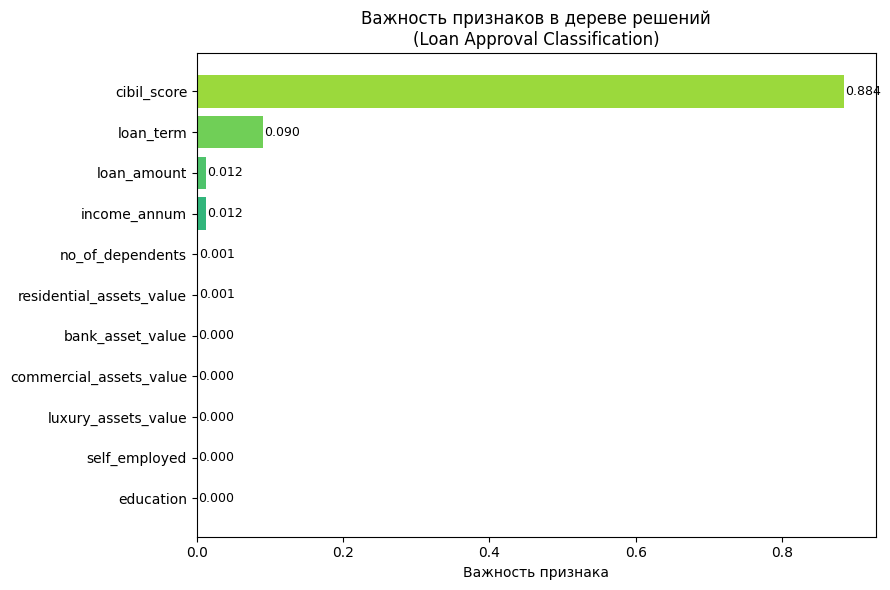

In [8]:
plt.figure(figsize=(9, 6))

importances = tree.feature_importances_
features = X.columns
indices = np.argsort(importances)

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(features)))
bars = plt.barh(
    [features[i] for i in indices],
    importances[indices],
    color=colors
)

for bar, val in zip(bars, importances[indices]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений\n(Loan Approval Classification)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

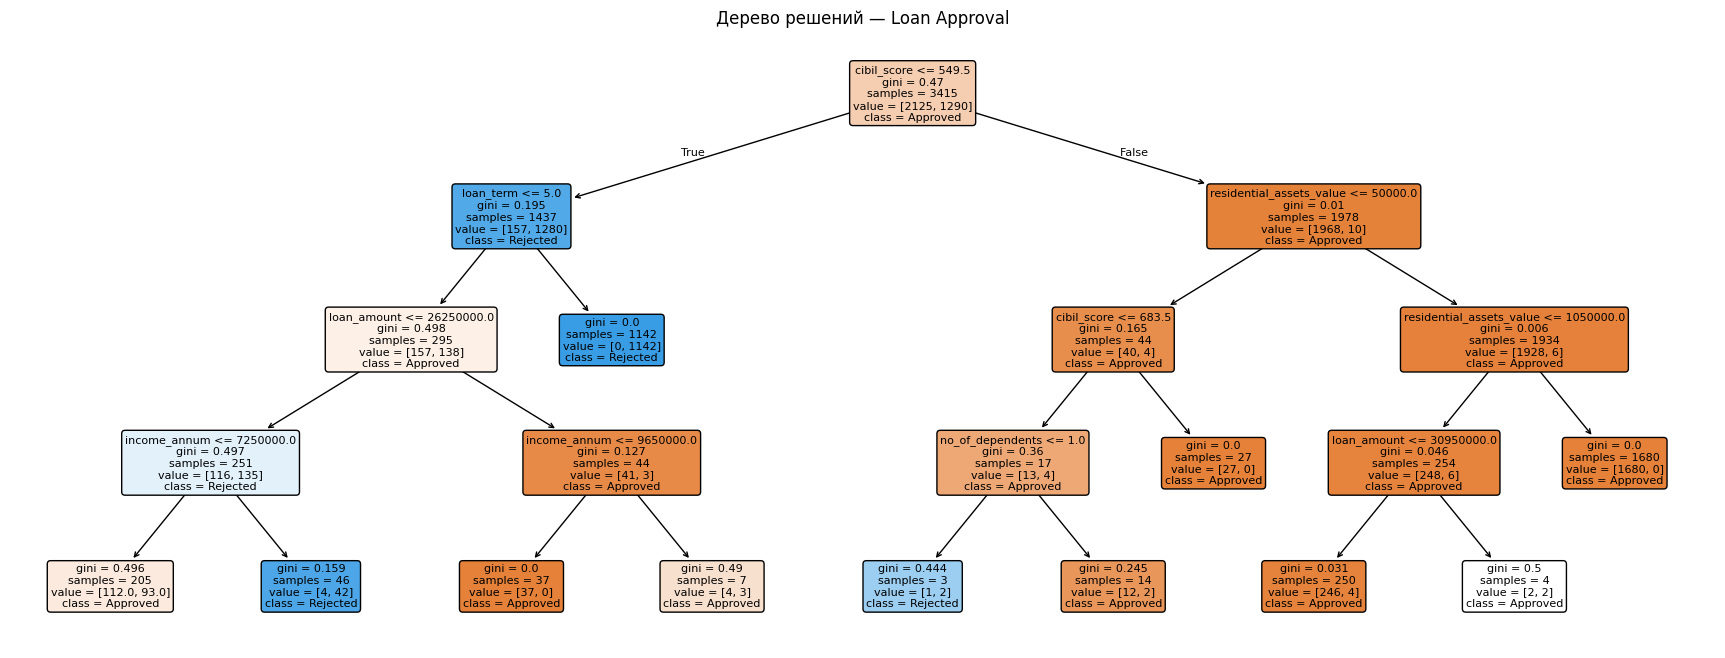

Правила дерева решений:
|--- cibil_score <= 549.50
|   |--- loan_term <= 5.00
|   |   |--- loan_amount <= 26250000.00
|   |   |   |--- income_annum <= 7250000.00
|   |   |   |   |--- class: 0
|   |   |   |--- income_annum >  7250000.00
|   |   |   |   |--- class: 1
|   |   |--- loan_amount >  26250000.00
|   |   |   |--- income_annum <= 9650000.00
|   |   |   |   |--- class: 0
|   |   |   |--- income_annum >  9650000.00
|   |   |   |   |--- class: 0
|   |--- loan_term >  5.00
|   |   |--- class: 1
|--- cibil_score >  549.50
|   |--- residential_assets_value <= 50000.00
|   |   |--- cibil_score <= 683.50
|   |   |   |--- no_of_dependents <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- no_of_dependents >  1.00
|   |   |   |   |--- class: 0
|   |   |--- cibil_score >  683.50
|   |   |   |--- class: 0
|   |--- residential_assets_value >  50000.00
|   |   |--- residential_assets_value <= 1050000.00
|   |   |   |--- loan_amount <= 30950000.00
|   |   |   |   |--- class: 0
|   |   |   

In [9]:
# Графическая визуализация
plt.figure(figsize=(22, 8))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=['Approved', 'Rejected'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Дерево решений — Loan Approval')
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# Текстовые правила
print("Правила дерева решений:")
print(export_text(tree, feature_names=list(X.columns)))